In [16]:
import pandas as pd
import itertools
inicio = time.time()

# CARREGAR CSV
df = pd.read_csv('2x2_score_feature_cv.csv')

# GARANTIR TOPS

top_cv = df.sort_values('CV_ROC_AUC', ascending=False).head(3)
top_ap = df.sort_values('Average_Precision', ascending=False).head(3)
top_ks = df.sort_values('KS_Conjunto', ascending=False).head(3)

# EXTRAIR FEATURES

features_cv = set(top_cv['Feature_1']).union(set(top_cv['Feature_2']))
features_ap = set(top_ap['Feature_1']).union(set(top_ap['Feature_2']))
features_ks = set(top_ks['Feature_1']).union(set(top_ks['Feature_2']))

# UNIÃO FINAL


features_all = features_cv.union(features_ap).union(features_ks)

print("\nFeatures selecionadas:")
print(features_all)


# GERAR DUPLAS

combinacoes = itertools.combinations(features_all, 2)


# REMOVER DUPLICATAS LÓGICAS


duplas_unicas = set()

for f1, f2 in combinacoes:

    dupla = tuple(sorted([f1, f2]))  # garante ordem única
    duplas_unicas.add(dupla)

# RESULTADO FINAL

duplas_unicas = list(duplas_unicas)

print(f"\nTotal de duplas únicas: {len(duplas_unicas)}\n")

for f1, f2 in duplas_unicas:
    print(f"{f1} / {f2}")

duplas_lista = list(duplas_unicas)


Features selecionadas:
{'V12', 'V14', 'V10', 'V4'}

Total de duplas únicas: 6

V12 / V4
V10 / V4
V10 / V14
V14 / V4
V10 / V12
V12 / V14


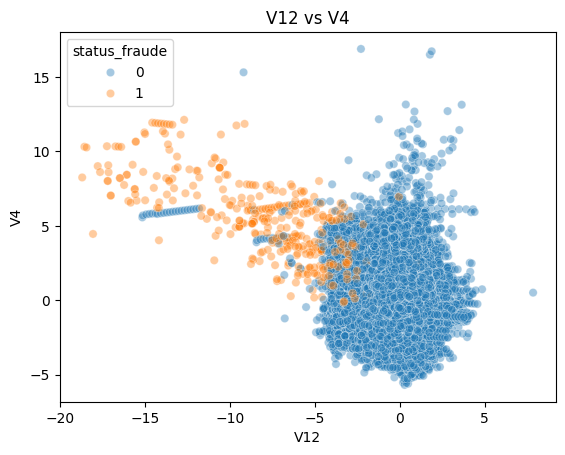

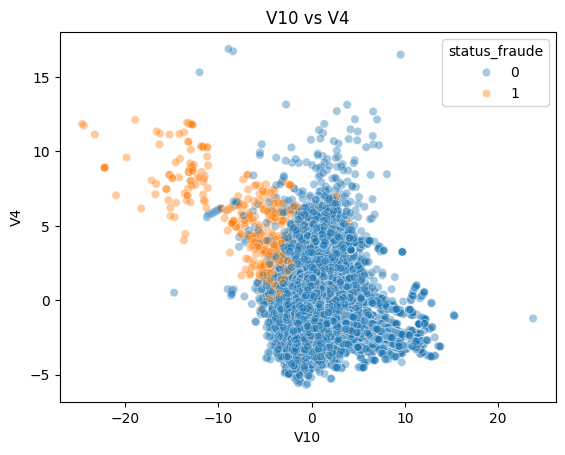

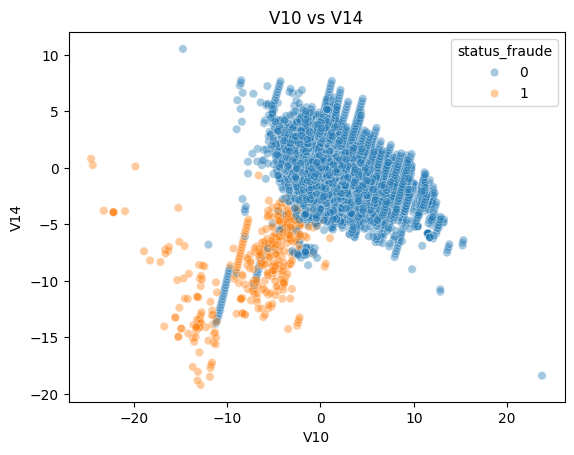

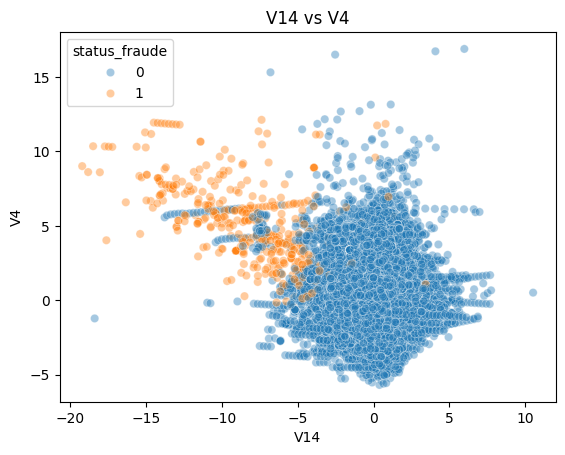

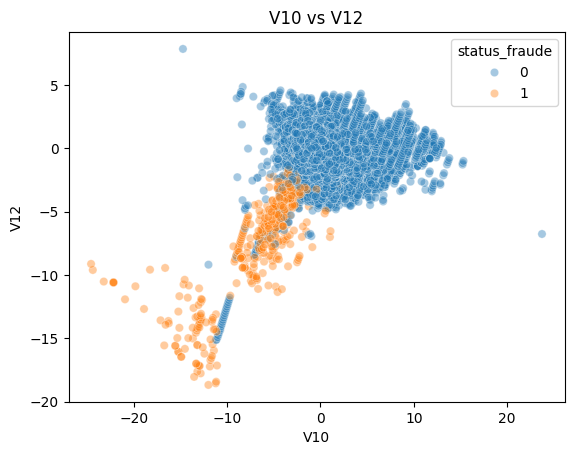

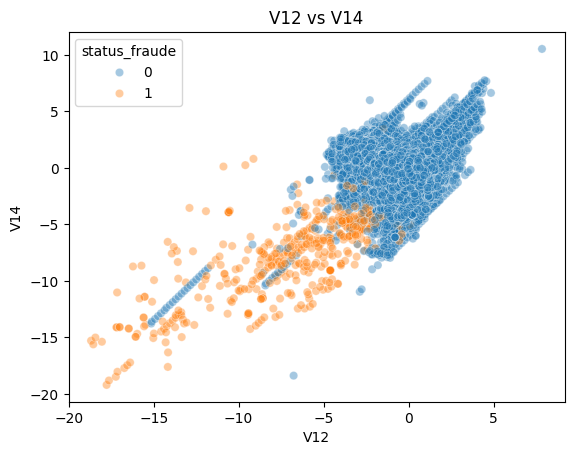

In [17]:
df = pd.read_csv('creditcard.csv')

for f1, f2 in duplas_lista:

    if f1 not in df.columns or f2 not in df.columns:
        print(f"Pulando {f1}, {f2} (não existe no df)")
        continue

    sns.scatterplot(
        data=df,
        x=f1,
        y=f2,
        hue='status_fraude',
        alpha=0.4
    )

    plt.title(f"{f1} vs {f2}")
    plt.show()

In [18]:
fim = time.time()
tempo_total = fim - inicio

print(f"Tempo de execução: {tempo_total:.4f} segundos")

Tempo de execução: 43.4434 segundos
